## Chapter 1 of *lme4: Mixed-effects modeling with R* (2022)

In [1]:
from hea.R import *
from hea.plot import *
from hea import data, lm, lme

### 1.2.1

In [2]:
Dyestuff = data("Dyestuff")
head(Dyestuff)

Batch,Yield
enum,i64
"""A""",1545
"""A""",1440
"""A""",1440
"""A""",1520
"""A""",1580
"""B""",1540


In [3]:
summary(Dyestuff)

Batch     Yield
A:5    Min.   :1440
B:5    1st Qu.:1469
C:5    Median :1530
D:5    Mean   :1528
E:5    3rd Qu.:1575
F:5    Max.   :1635

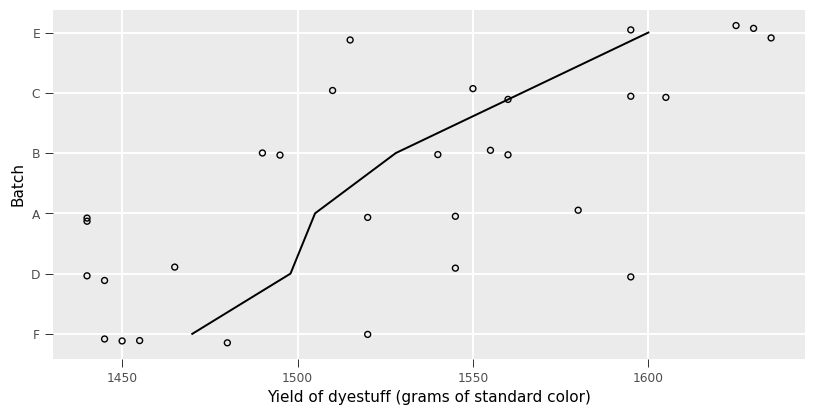

In [4]:
from hea import fct_reorder

dye_ord = Dyestuff.mutate(Batch=fct_reorder("Batch", "Yield"))

(
    dye_ord
        .ggplot(x="Yield", y="Batch")
        .geom_jitter(height=0.15, width=0, shape=1)
        .stat_summary(geom='line', fun='mean', group=1)
        .labs(x="Yield of dyestuff (grams of standard color)", y="Batch")
).show(figsize=(8, 4))


### 1.2.2

In [5]:
Dyestuff2 = data("Dyestuff2")
summary(Dyestuff2)

Batch       Yield
A:5    Min.   :-0.8920
B:5    1st Qu.: 2.7650
C:5    Median : 5.3650
D:5    Mean   : 5.6656
E:5    3rd Qu.: 8.1510
F:5    Max.   :13.4340

### 1.3.1

In [6]:
fm01 = lme("Yield ~ 1 + (1 | Batch)", Dyestuff)
summary(fm01)

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1 | Batch)

REML criterion at convergence: 319.6543

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4117 -0.7634 0.1418 0.7792 1.8296

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1764     42.00
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   1527.50       19.38    78.80


In [7]:
summary(fm01ML := lme("Yield ~ 1 + (1 | Batch)", Dyestuff, REML=False))

Linear mixed model fit by maximum likelihood
Formula: Yield ~ 1 + (1 | Batch)

     AIC      BIC    logLik -2*log(L) df.resid
333.3271 337.5307 -163.6635  327.3271       27

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4315 -0.7972 0.1480 0.7721 1.8037

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1388     37.26
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   1527.50       17.69    86.33


In [8]:
summary(fm02 := lme("Yield ~ 1 + (1 | Batch)", Dyestuff2))

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1 | Batch)

REML criterion at convergence: 161.8283

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.7648 -0.7806 -0.0809 0.6689 2.0907

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 0.00     0.000
 Residual             13.81    3.716
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    5.6656      0.6784    8.352


In [9]:
summary(fm02ML := update(fm02, REML=False))

Linear mixed model fit by maximum likelihood
Formula: Yield ~ 1 + (1 | Batch)

     AIC      BIC   logLik -2*log(L) df.resid
168.8730 173.0766 -81.4365  162.8730       27

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.7950 -0.7940 -0.0823 0.6803 2.1264

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 0.00     0.000
 Residual             13.35    3.653
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    5.6656      0.6670    8.494


In [10]:
summary(fm02a := lm("Yield ~ 1", Dyestuff2))

Formula: Yield ~ 1

Residuals:
    Min      1Q  Median     3Q    Max
-6.5576 -2.9006 -0.3006 2.4854 7.7684

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    5.6656      0.6784     4.278      7.053    8.352  3.32e-09  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 30, p = 1, Residual SE = 3.716 on 29 DF
R-Squared = 0.0000, adjusted R-Squared = 0.0000
Log Likelihood = -81.4365, AIC = 166.8730, BIC = 169.6754


### 1.4.2

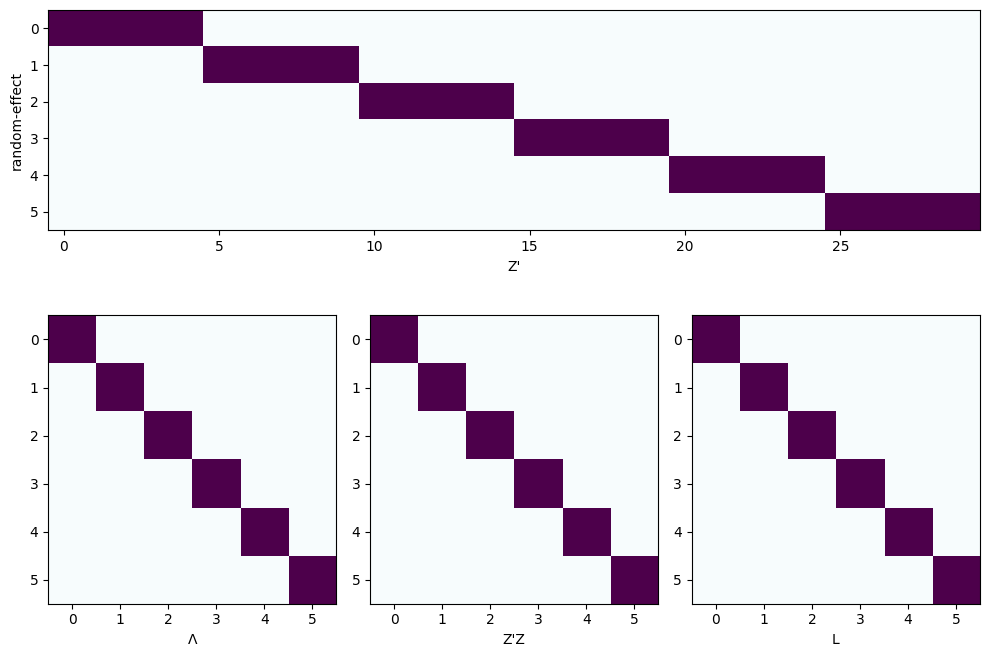

In [11]:
_ = fm01ML.plot_design()

In [12]:
fm01ML.Lambda

array([[0.7525928, 0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.7525928, 0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.7525928, 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.7525928, 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.7525928, 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.       , 0.7525928]])

In [13]:
fm01.Z.T

array([[1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.]])

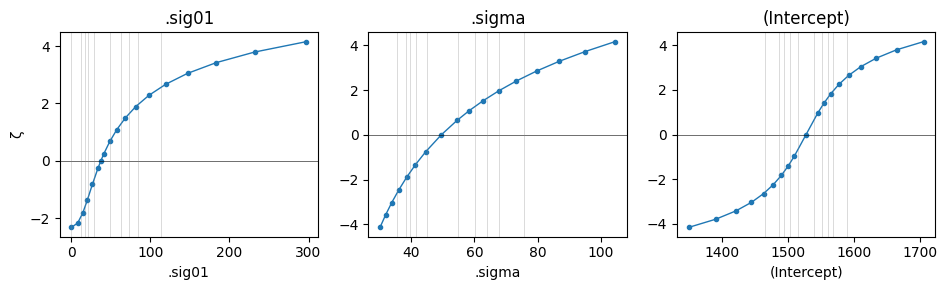

In [14]:
pr01 = fm01ML.profile()
confint(pr01)
_ = pr01.plot()

In [15]:
confint(pr01)

parameter,2.5%,97.5%
str,f64,f64
""".sig01""",12.223433,84.062705
""".sigma""",38.230035,67.657672
"""(Intercept)""",1486.452021,1568.547979


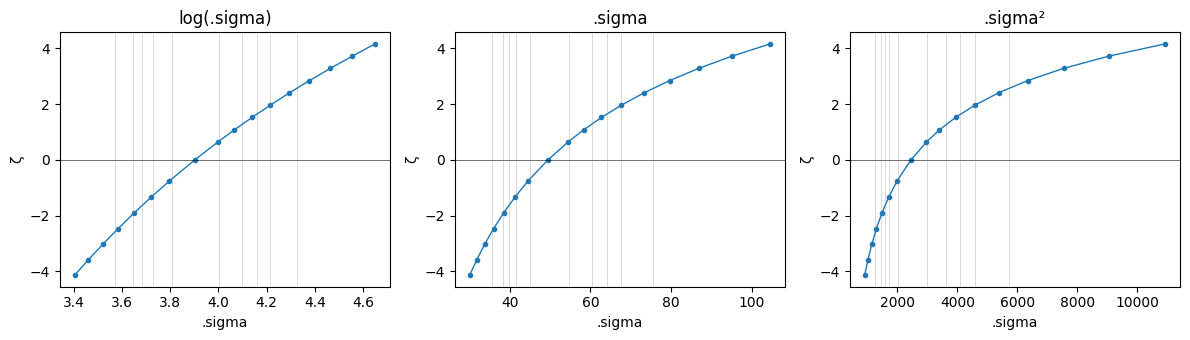

In [16]:
with par(mfrow=(1,3)):
    pr01.plot(which=".sigma", transform="log")
    pr01.plot(which=".sigma")
    pr01.plot(which=".sigma", transform="square")

/Users/ziweih/Works/hea/hea/lme.py:1518: RuntimeWarning: divide by zero encountered in log
  x_at = fwd(np.asarray(v_at)).item()


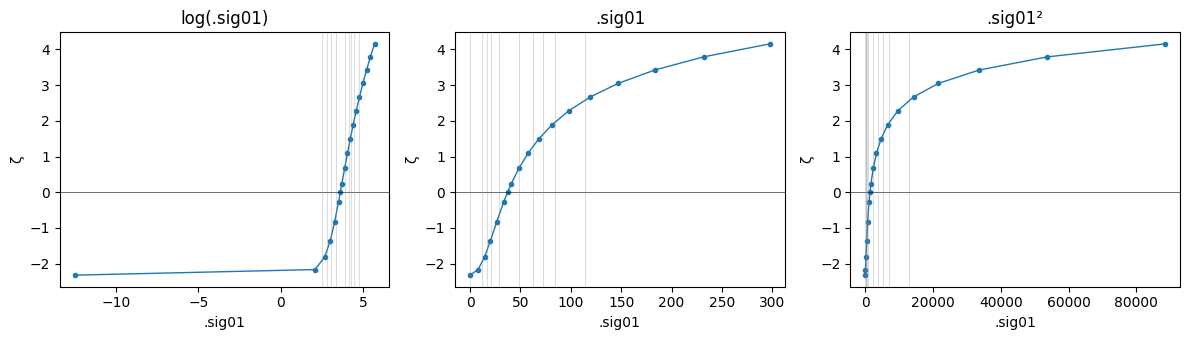

In [17]:
with par(mfrow=(1,3)):
    pr01.plot(which=".sig01", transform="log")
    pr01.plot(which=".sig01")
    pr01.plot(which=".sig01", transform="square")

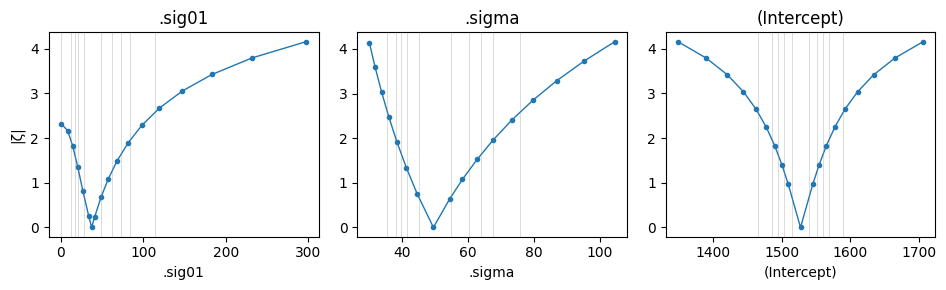

In [18]:
_ = pr01.plot(absolute=True)

In [19]:
confint(pr01, level = 0.99)

parameter,0.5%,99.5%
str,f64,f64
""".sig01""",0.0,113.687518
""".sigma""",35.562897,75.666452
"""(Intercept)""",1465.872759,1589.127241


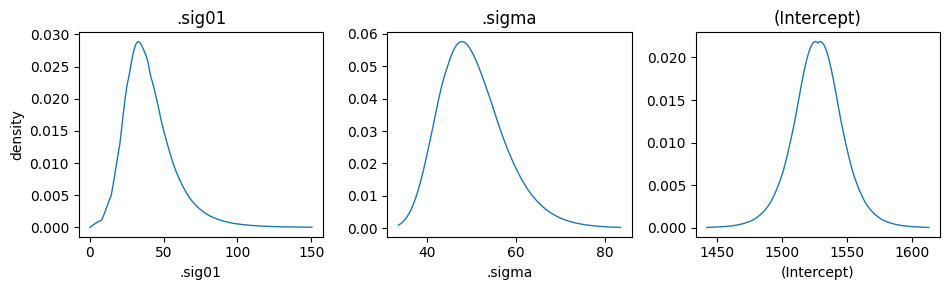

In [20]:
_ = pr01.plot_density()

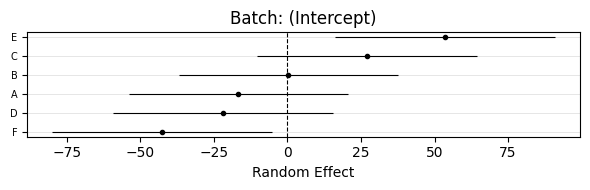

In [21]:
_ = fm01ML.plot_ranef(figsize=(6, 2))

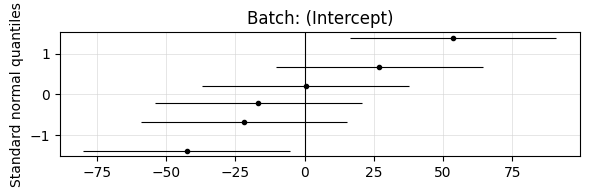

In [22]:
_ = fm01ML.plot_qq_ranef(figsize=(6, 2))